# เนื้อหา

1. การเตรียมข้อมูล (Data Preparation)
ส่วนนี้เป็นการสร้างชุดข้อมูลความต้องการ Personal Computer ตามสไลด์หน้า 9

In [5]:
import pandas as pd
import numpy as np

# ข้อมูลความต้องการสินค้า (A_t)
data_pc = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct'],
    't': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'A_t': [120, 90, 100, 75, 110, 50, 75, 130, 110, 90]
}
df = pd.DataFrame(data_pc)
print("--- ตารางข้อมูลตั้งต้น (PC Demand) ---")
print(df)

--- ตารางข้อมูลตั้งต้น (PC Demand) ---
  Month   t  A_t
0   Jan   1  120
1   Feb   2   90
2   Mar   3  100
3   Apr   4   75
4   May   5  110
5   Jun   6   50
6   Jul   7   75
7   Aug   8  130
8   Sep   9  110
9   Oct  10   90


2. Simple Moving Average (SMA)ตัวอย่าง: สไลด์หน้า 9 (คำนวณค่าพยากรณ์ $n=3$) 2สูตร: $F_{t} = \frac{\sum A_{t-i}}{n}$

In [6]:
# --- กำหนดตัวแปร ---
n = 3

# --- การคำนวณ ---
# ใช้ rolling mean และ shift(1) เพราะพยากรณ์เดือนปัจจุบัน ต้องใช้ข้อมูลเดือน "ก่อนหน้า"
df['SMA_3'] = df['A_t'].rolling(window=n).mean().shift(1)

print(f"\n--- Simple Moving Average (n={n}) ---")
print(df[['Month', 'A_t', 'SMA_3']])


--- Simple Moving Average (n=3) ---
  Month  A_t       SMA_3
0   Jan  120         NaN
1   Feb   90         NaN
2   Mar  100         NaN
3   Apr   75  103.333333
4   May  110   88.333333
5   Jun   50   95.000000
6   Jul   75   78.333333
7   Aug  130   78.333333
8   Sep  110   85.000000
9   Oct   90  105.000000


In [7]:
# --- กำหนดตัวแปร ---
n = 5

# --- การคำนวณ ---
# ใช้ rolling mean และ shift(1) เพราะพยากรณ์เดือนปัจจุบัน ต้องใช้ข้อมูลเดือน "ก่อนหน้า"
df['SMA_5'] = df['A_t'].rolling(window=n).mean().shift(1)

print(f"\n--- Simple Moving Average (n={n}) ---")
print(df[['Month', 'A_t', 'SMA_5']])


--- Simple Moving Average (n=5) ---
  Month  A_t  SMA_5
0   Jan  120    NaN
1   Feb   90    NaN
2   Mar  100    NaN
3   Apr   75    NaN
4   May  110    NaN
5   Jun   50   99.0
6   Jul   75   85.0
7   Aug  130   82.0
8   Sep  110   88.0
9   Oct   90   95.0


3. Weighted Moving Average (WMA)ตัวอย่าง: สไลด์หน้า 11 (พยากรณ์เดือน Nov) สูตร: $F_{t} = \sum W_{i}A_{t-i}$

In [8]:
# --- กำหนดตัวแปร ---
# ข้อมูลเดือน Aug, Sep, Oct เพื่อพยากรณ์ Nov
demands = [130, 110, 90]  # [Aug, Sep, Oct] -> [A_t-3, A_t-2, A_t-1]
weights = [0.17, 0.33, 0.50] # [W3, W2, W1] น้ำหนักเรียงจากไกลไปใกล้ (Aug->Oct)

# --- การคำนวณ ---
# F_11 = (0.17 * 130) + (0.33 * 110) + (0.50 * 90)
F_Nov = (weights[0] * demands[0]) + (weights[1] * demands[1]) + (weights[2] * demands[2])

print(f"\n--- Weighted Moving Average (Forecast for Nov) ---")
print(f"Calculation: ({weights[0]}*{demands[0]}) + ({weights[1]}*{demands[1]}) + ({weights[2]}*{demands[2]})")
print(f"Forecast Result: {F_Nov:.2f}")


--- Weighted Moving Average (Forecast for Nov) ---
Calculation: (0.17*130) + (0.33*110) + (0.5*90)
Forecast Result: 103.40


4. Exponential Smoothingตัวอย่าง: สไลด์หน้า 13 (Alpha = 0.5) 6สูตร: $F_{t} = F_{t-1} + \alpha(A_{t-1} - F_{t-1})$ 7

In [12]:
import pandas as pd
import numpy as np

# 1. ต้องสร้าง DataFrame ให้เสร็จก่อน เพื่อให้ทราบขนาด (len) ที่แน่นอน 
data_pc = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    't': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'A_t': [37, 40, 41, 37, 45, 50, 43, 47, 56, 52, 55, 54]
}
df = pd.DataFrame(data_pc)

# 2. กำหนดตัวแปรหลังจากที่เรารู้ขนาดของ df แล้ว
alpha = 0.5
forecasts = [np.nan] * len(df) 

# 3. เงื่อนไขเริ่มต้นตามเอกสารหน้า 13: F2 = A1 
# (Index ใน Python เริ่มที่ 0 ดังนั้น F2 คือ index 1 และ A1 คือ index 0)
forecasts[1] = df.loc[0, 'A_t']

# 4. การคำนวณหาค่าพยากรณ์ถัดไป (เริ่มจาก t=2 เพื่อหา F ของเดือนที่ 3) [cite: 188, 195]
for t in range(2, len(df)):
    F_prev = forecasts[t-1]
    A_prev = df.loc[t-1, 'A_t']
    
    # ใช้สูตร: Ft = Ft-1 + alpha * (At-1 - Ft-1) [cite: 188, 190]
    F_new = F_prev + alpha * (A_prev - F_prev)
    forecasts[t] = F_new

df['Exp_Smooth'] = forecasts
print(df[['Month', 'A_t', 'Exp_Smooth']])

   Month  A_t  Exp_Smooth
0    Jan   37         NaN
1    Feb   40   37.000000
2    Mar   41   38.500000
3    Apr   37   39.750000
4    May   45   38.375000
5    Jun   50   41.687500
6    Jul   43   45.843750
7    Aug   47   44.421875
8    Sep   56   45.710938
9    Oct   52   50.855469
10   Nov   55   51.427734
11   Dec   54   53.213867


5. Adjusted Exponential Smoothing (Trend)

ตัวอย่าง: สไลด์หน้า 15 (Alpha = 0.5, Beta = 0.3) สูตร: มี 3 ขั้นตอน (FWT, Level, Trend)

In [16]:
import pandas as pd
import numpy as np

# 1. เตรียมข้อมูล 12 เดือนแรก
data_pc = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'A_t': [37, 40, 41, 37, 45, 50, 43, 47, 56, 52, 55, 54]
}
df = pd.DataFrame(data_pc)

# 2. เพิ่มแถวที่ 13 (Jan ปีถัดไป) เพื่อใช้เก็บค่าพยากรณ์เป้าหมาย
new_row = pd.DataFrame({'Month': ['Jan_Next'], 'A_t': [np.nan]})
df = pd.concat([df, new_row], ignore_index=True)

# 3. กำหนดตัวแปร
alpha = 0.5 
beta = 0.3  
level = [0.0] * len(df)
trend = [0.0] * len(df)
fwt = [0.0] * len(df)

# 4. เงื่อนไขเริ่มต้น (หน้า 15): เริ่มที่ index 1 (Feb)
level[1] = float(df.loc[0, 'A_t']) # F2 = A1 
trend[1] = 0.0                     # T2 = 0  
fwt[1] = level[1] + trend[1]       # FWT2 = F2 + T2 [cite: 231]

# 5. วนลูปคำนวณตั้งแต่เดือนที่ 3 (index 2) จนถึงเดือนที่ 13 (index 12)
for t in range(2, len(df)):
    A_prev = df.loc[t-1, 'A_t']
    FWT_prev = fwt[t-1]
    Trend_prev = trend[t-1]
    
    # สูตร: Ft = FWTt-1 + alpha(At-1 - FWTt-1) [cite: 232]
    level[t] = round(FWT_prev + alpha * (A_prev - FWT_prev), 2)
    
    # สูตร: Tt = Tt-1 + beta(Ft - FWTt-1) [cite: 233]
    trend[t] = round(Trend_prev + beta * (level[t] - FWT_prev), 2)
    
    # สูตร: FWTt = Ft + Tt [cite: 231]
    fwt[t] = round(level[t] + trend[t], 2)

# เก็บค่าลง DataFrame
df['F_t'] = level
df['T_t'] = trend
df['Exp_Trend_FWT'] = fwt

# แสดงผลเปรียบเทียบกับหน้า 15
print(df[['Month', 'A_t', 'F_t', 'T_t', 'Exp_Trend_FWT']])

       Month   A_t    F_t   T_t  Exp_Trend_FWT
0        Jan  37.0   0.00  0.00           0.00
1        Feb  40.0  37.00  0.00          37.00
2        Mar  41.0  38.50  0.45          38.95
3        Apr  37.0  39.98  0.76          40.74
4        May  45.0  38.87  0.20          39.07
5        Jun  50.0  42.04  1.09          43.13
6        Jul  43.0  46.56  2.12          48.68
7        Aug  47.0  45.84  1.27          47.11
8        Sep  56.0  47.06  1.26          48.32
9        Oct  52.0  52.16  2.41          54.57
10       Nov  55.0  53.28  2.02          55.30
11       Dec  54.0  55.15  1.98          57.13
12  Jan_Next   NaN  55.56  1.51          57.07


6. Linear Regressionตัวอย่าง: สไลด์หน้า 18 10สูตร: $b = \frac{\sum XY - n\bar{X}\bar{Y}}{\sum X^2 - n\bar{X}^2}$, $a = \bar{Y} - b\bar{X}$ 11

In [29]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# 1. เตรียมข้อมูลพื้นฐาน (อ้างอิงหน้า 18) 
data = {
    'เดือน': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'ความต้องการ (Y)': [37, 40, 41, 37, 45, 50, 43, 47, 56, 52, 55, 54]
}
df = pd.DataFrame(data)
df.insert(1, 'หน่วยเวลา (X)', range(1, 13))

# 2. คำนวณคอลัมน์สำหรับการพยากรณ์ 
df['XY'] = df['หน่วยเวลา (X)'] * df['ความต้องการ (Y)']
df['X^2'] = df['หน่วยเวลา (X)']**2
df['Y^2'] = df['ความต้องการ (Y)']**2

# 3. คำนวณแถวสรุปผล (Summary Rows) 
sum_row = df.select_dtypes(include=[np.number]).sum()
mean_row = df.select_dtypes(include=[np.number]).mean()

# สร้าง DataFrame สำหรับแถวสรุป
summary_df = pd.DataFrame([sum_row, mean_row], index=['รวม', 'เฉลี่ย'])
summary_df['เดือน'] = summary_df.index
full_df = pd.concat([df, summary_df]).reset_index(drop=True)

# 4. การจัดรูปแบบตาราง (Styling)
def style_regression_table(styler):
    styler.set_caption("ตารางคำนวณการพยากรณ์ด้วยวิธี Linear Regression (หน้า 18)")
    styler.format(precision=2)
    # แก้ไข: นำ q=None ออกเพื่อให้รันได้ปกติ
    styler.format(subset=['หน่วยเวลา (X)', 'ความต้องการ (Y)', 'XY', 'X^2', 'Y^2'], precision=0) 
    
    # ไฮไลต์แถว รวม และ เฉลี่ย เป็นสีเหลืองเหมือนในเอกสาร 
    styler.set_properties(subset=pd.IndexSlice[full_df.index[-2:], :], 
                         **{'background-color': '#ffff00', 'font-weight': 'bold'})
    
    styler.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('border', '1px solid black')]},
        {'selector': 'td', 'props': [('border', '1px solid #ccc'), ('text-align', 'center')]}
    ])
    return styler

# แสดงผลตาราง
display(style_regression_table(full_df.style))

# 5. คำนวณค่าพารามิเตอร์ตามสูตรในหน้า 18 [cite: 271, 272, 280]
n = 12
b = (sum_row['XY'] - n * mean_row['หน่วยเวลา (X)'] * mean_row['ความต้องการ (Y)']) / (sum_row['X^2'] - n * mean_row['หน่วยเวลา (X)']**2)
a = mean_row['ความต้องการ (Y)'] - b * mean_row['หน่วยเวลา (X)']
r = (n * sum_row['XY'] - sum_row['หน่วยเวลา (X)'] * sum_row['ความต้องการ (Y)']) / \
    np.sqrt((n * sum_row['X^2'] - sum_row['หน่วยเวลา (X)']**2) * (n * sum_row['Y^2'] - sum_row['ความต้องการ (Y)']**2))

# 6. แสดงสรุปผลลัพธ์ด้วย HTML และ LaTeX [cite: 282, 283]
display(HTML(f"""
<div style="background-color: #f0f7fb; padding: 20px; border-radius: 10px; border-left: 5px solid #2196F3; margin-top: 20px;">
    <h3 style="margin-top: 0;">ผลลัพธ์การคำนวณ (Summary)</h3>
    <table style="width: 100%; border-collapse: collapse;">
        <tr><td><b>ค่า Slope (b):</b></td><td>{b:.2f}</td></tr>
        <tr><td><b>จุดตัดแกน Y (a):</b></td><td>{a:.1f}</td></tr>
        <tr><td><b>สมการพยากรณ์:</b></td><td>$Y = {a:.1f} + {b:.2f}X$</td></tr>
        <tr><td><b>สัมประสิทธิ์สหสัมพันธ์ (r):</b></td><td>{r:.3f}</td></tr>
        <tr><td><b>ความเชื่อถือได้ ($R^2$):</b></td><td>{r**2:.3f} (ประมาณ {r**2*100:.1f}%)</td></tr>
    </table>
    <hr>
    <p style="color: #d32f2f; font-size: 1.1em;"><b>พยากรณ์เดือนมกราคมปีถัดไป (t=13):</b><br>
    $Y_{{13}} = {a:.1f} + {b:.2f}(13) = {a + b*13:.2f} \approx {round(a + b*13)} \text{{ เครื่อง}}$</p> 
</div>
"""))

,เดือน,หน่วยเวลา (X),ความต้องการ (Y),XY,X^2,Y^2
0,Jan,1,37,37,1,1369
1,Feb,2,40,80,4,1600
2,Mar,3,41,123,9,1681
3,Apr,4,37,148,16,1369
4,May,5,45,225,25,2025
5,Jun,6,50,300,36,2500
6,Jul,7,43,301,49,1849
7,Aug,8,47,376,64,2209
8,Sep,9,56,504,81,3136
9,Oct,10,52,520,100,2704


ค่า Slope (b):,1.72
จุดตัดแกน Y (a):,35.2
สมการพยากรณ์:,$Y = 35.2 + 1.72X$
สัมประสิทธิ์สหสัมพันธ์ (r):,0.896
ความเชื่อถือได้ ($R^2$):,0.803 (ประมาณ 80.3%)


In [30]:
import pandas as pd
import numpy as np

# ข้อมูลความต้องการเครื่องคอมพิวเตอร์ (หน้า 18)
data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'X': range(1, 13), # หน่วยเวลา (t)
    'Y': [37, 40, 41, 37, 45, 50, 43, 47, 56, 52, 55, 54] # ความต้องการ (At)
}
df = pd.DataFrame(data)

# 1. คำนวณค่าพื้นฐานสำหรับตาราง (หน้า 18)
df['XY'] = df['X'] * df['Y']
df['X2'] = df['X']**2
df['Y2'] = df['Y']**2

n = len(df)
sum_x = df['X'].sum()
sum_y = df['Y'].sum()
sum_xy = df['XY'].sum()
sum_x2 = df['X2'].sum()
sum_y2 = df['Y2'].sum()
mean_x = sum_x / n
mean_y = sum_y / n

# 2. คำนวณค่า b (Slope) ตามสูตรในหน้า 16
# สูตร: b = (ΣXY - n * mean_X * mean_Y) / (ΣX^2 - n * mean_X^2)
b_numerator = sum_xy - (n * mean_x * mean_y)
b_denominator = sum_x2 - (n * (mean_x**2))
b = b_numerator / b_denominator

# 3. คำนวณค่า a (Intercept) ตามสูตรในหน้า 16
# สูตร: a = mean_Y - b * mean_X
a = mean_y - (b * mean_x)

# 4. คำนวณค่าสัมประสิทธิ์สหสัมพันธ์ (r) ตามสูตรในหน้า 17
# สูตร: r = (nΣXY - ΣXΣY) / sqrt([nΣX^2 - (ΣX)^2][nΣY^2 - (ΣY)^2])
r_num = (n * sum_xy) - (sum_x * sum_y)
r_den_part1 = (n * sum_x2) - (sum_x**2)
r_den_part2 = (n * sum_y2) - (sum_y**2)
r = r_num / np.sqrt(r_den_part1 * r_den_part2)
r2 = r**2

# 5. พยากรณ์เดือนที่ 13 (January ปีถัดไป)
x_13 = 13
y_13 = a + (b * x_13)

# --- แสดงผลลัพธ์แต่ละค่าที่คำนวณได้ ---
print(f"--- 1. ค่ารวมและค่าเฉลี่ย (Totals & Means) ---")
print(f"n = {n}")
print(f"ΣX = {sum_x}, ΣY = {sum_y}")
print(f"ΣXY = {sum_xy}, ΣX² = {sum_x2}, ΣY² = {sum_y2}")
print(f"X̄ = {mean_x:.2f}, Ȳ = {mean_y:.2f}")

print(f"\n--- 2. การหาค่า b (Slope) ---")
print(f"b = ({sum_xy} - {n} * {mean_x:.2f} * {mean_y:.2f}) / ({sum_x2} - {n} * {mean_x:.2f}²)")
print(f"b = {b_numerator:.2f} / {b_denominator:.2f} = {b:.2f}")

print(f"\n--- 3. การหาค่า a (Intercept) ---")
print(f"a = {mean_y:.2f} - ({b:.2f} * {mean_x:.2f})")
print(f"a = {a:.1f}")

print(f"\n--- 4. ความสัมพันธ์และความแม่นยำ (r & R²) ---")
print(f"r = {r:.3f}")
print(f"R² = {r2:.3f}")

print(f"\n--- 5. ผลการพยากรณ์เดือนที่ 13 ---")
print(f"Y₁₃ = {a:.1f} + {b:.2f} * 13 = {y_13:.2f} ≈ {round(y_13)}")

--- 1. ค่ารวมและค่าเฉลี่ย (Totals & Means) ---
n = 12
ΣX = 78, ΣY = 557
ΣXY = 3867, ΣX² = 650, ΣY² = 26383
X̄ = 6.50, Ȳ = 46.42

--- 2. การหาค่า b (Slope) ---
b = (3867 - 12 * 6.50 * 46.42) / (650 - 12 * 6.50²)
b = 246.50 / 143.00 = 1.72

--- 3. การหาค่า a (Intercept) ---
a = 46.42 - (1.72 * 6.50)
a = 35.2

--- 4. ความสัมพันธ์และความแม่นยำ (r & R²) ---
r = 0.896
R² = 0.803

--- 5. ผลการพยากรณ์เดือนที่ 13 ---
Y₁₃ = 35.2 + 1.72 * 13 = 57.62 ≈ 58


7. Seasonality (Seasonal Index)ตัวอย่าง: สไลด์หน้า 19 (รถยนต์) สูตร: $S_i = \frac{D_i}{\sum D_k}$

In [34]:
# --- กำหนดตัวแปร ---
# ข้อมูลยอดจองรถ 3 ปี แยกรายไตรมาส
# แถว = ปี, คอลัมน์ = ไตรมาส 1, 2, 3, 4
data_seasonal = np.array([
    [12.6, 8.6, 6.3, 17.5],
    [14.1, 10.3, 7.5, 18.2],
    [15.3, 10.6, 8.1, 19.6]
])

# --- การคำนวณ ---
total_demand_all_years = np.sum(data_seasonal) # 148.7
total_demand_per_quarter = np.sum(data_seasonal, axis=0) # [Q1_sum, Q2_sum, Q3_sum, Q4_sum]

# คำนวณ Seasonal Index
seasonal_indices = total_demand_per_quarter / total_demand_all_years

print(f"\n--- Seasonal Indices ---")
for i, idx in enumerate(seasonal_indices):
    print(f"Quarter {i+1}: {idx:.2f}")


--- Seasonal Indices ---
Quarter 1: 0.28
Quarter 2: 0.20
Quarter 3: 0.15
Quarter 4: 0.37


8. Error Metrics (MAD, MSE, MAPD)

ตัวอย่าง: สไลด์หน้า 23 (ใช้ข้อมูล Moving Average) สูตร: ตามหน้า 22

In [38]:
import pandas as pd
import numpy as np

# 1. เตรียมข้อมูลพื้นฐาน
data = {
    'หน่วยเวลา': np.arange(1, 14),
    'เดือน': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan'],
    'ความต้องการ (At)': [37, 40, 41, 37, 45, 50, 43, 47, 56, 52, 55, 54, np.nan]
}

df = pd.DataFrame(data)

# 2. คำนวณ Moving Average (n=3)
# ใช้ shift(1) เพื่อให้ค่าพยากรณ์ของเดือนนี้ มาจากค่าเฉลี่ยของ 3 เดือนก่อนหน้า
df['Moving Average n=3'] = df['ความต้องการ (At)'].rolling(window=3).mean().shift(1)

# 3. คำนวณ Error ต่างๆ (คำนวณเฉพาะแถวที่มีทั้ง At และ Ft)
df['At - Ft'] = df['ความต้องการ (At)'] - df['Moving Average n=3']
df['(At - Ft)^2'] = df['At - Ft']**2
df['|At - Ft|'] = df['At - Ft'].abs()
df['|At - Ft| / |At|'] = df['|At - Ft|'] / df['ความต้องการ (At)']

# 4. คำนวณตัววัดประสิทธิภาพ (Metrics)
# เลือกเฉพาะช่วงที่มีการพยากรณ์ (เดือนที่ 4-12)
mask = df['At - Ft'].notna()
n = mask.sum()

sum_abs_error = df.loc[mask, '|At - Ft|'].sum()
sum_sq_error = df.loc[mask, '(At - Ft)^2'].sum()
sum_pct_error = df.loc[mask, '|At - Ft| / |At|'].sum()

mad = sum_abs_error / n
mse = sum_sq_error / n
mape = (sum_pct_error / n) * 100 # ในภาพใช้ชื่อ MAPD แต่คำนวณแบบ MAPE

# การจัดรูปแบบการแสดงผลตาราง
pd.options.display.float_format = '{:,.2f}'.format
print("ตารางวิเคราะห์การพยากรณ์ (Moving Average n=3)")
display(df.fillna('-'))

# แสดงผลสรุป
print(f"\n--- สรุปผลการวัดค่าความคลาดเคลื่อน (Count N = {n}) ---")
print(f"MAD  : {mad:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"MAPE (MAPD) : {mape:.2f}%")

ตารางวิเคราะห์การพยากรณ์ (Moving Average n=3)


,หน่วยเวลา,เดือน,ความต้องการ (At),Moving Average n=3,At - Ft,(At - Ft)^2,|At - Ft|,|At - Ft| / |At|
0,1,Jan,37.00,-,-,-,-,-
1,2,Feb,40.00,-,-,-,-,-
2,3,Mar,41.00,-,-,-,-,-
3,4,Apr,37.00,39.33,-2.33,5.44,2.33,0.06
4,5,May,45.00,39.33,5.67,32.11,5.67,0.13
5,6,Jun,50.00,41.00,9.00,81.00,9.00,0.18
6,7,Jul,43.00,44.00,-1.00,1.00,1.00,0.02
7,8,Aug,47.00,46.00,1.00,1.00,1.00,0.02
8,9,Sep,56.00,46.67,9.33,87.11,9.33,0.17
9,10,Oct,52.00,48.67,3.33,11.11,3.33,0.06



--- สรุปผลการวัดค่าความคลาดเคลื่อน (Count N = 9) ---
MAD  : 3.93
MSE  : 25.56
MAPE (MAPD) : 7.90%


In [39]:
import pandas as pd
import numpy as np

# 1. เตรียมข้อมูลพื้นฐาน
data = {
    'หน่วยเวลา': np.arange(1, 14),
    'เดือน': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan'],
    'ความต้องการ (At)': [37, 40, 41, 37, 45, 50, 43, 47, 56, 52, 55, 54, np.nan]
}

df = pd.DataFrame(data)

# 2. คำนวณ Exponential Smoothing (alpha = 0.5)
alpha = 0.5
forecast = [np.nan] * len(df)

# กำหนดค่าเริ่มต้น: F2 = A1 (ตามที่ปรากฏในภาพตัวอย่าง)
forecast[1] = df.loc[0, 'ความต้องการ (At)']

# คำนวณ Ft+1 = alpha * At + (1 - alpha) * Ft
for i in range(1, len(df) - 1):
    forecast[i+1] = (alpha * df.loc[i, 'ความต้องการ (At)']) + ((1 - alpha) * forecast[i])

df['Exponential alpha=0.5'] = forecast

# 3. คำนวณ Error ต่างๆ (คำนวณเฉพาะแถวที่มีทั้ง At และ Ft)
df['At - Ft'] = df['ความต้องการ (At)'] - df['Exponential alpha=0.5']
df['(At - Ft)^2'] = df['At - Ft']**2
df['|At - Ft|'] = df['At - Ft'].abs()
df['|At - Ft| / |At|'] = df['|At - Ft|'] / df['ความต้องการ (At)']

# 4. คำนวณตัววัดประสิทธิภาพ (Metrics)
# เลือกเฉพาะช่วงที่มีการพยากรณ์และมีค่าจริง (หน่วยเวลา 2-12)
mask = df['At - Ft'].notna()
n = mask.sum()

sum_abs_error = df.loc[mask, '|At - Ft|'].sum()
sum_sq_error = df.loc[mask, '(At - Ft)^2'].sum()
sum_pct_error = df.loc[mask, '|At - Ft| / |At|'].sum()

mad = sum_abs_error / n
mse = sum_sq_error / n
mapd = (sum_pct_error / n) * 100

# การจัดรูปแบบการแสดงผลตาราง
pd.options.display.float_format = '{:,.2f}'.format
print(f"ตารางวิเคราะห์การพยากรณ์ (Exponential Smoothing alpha = {alpha})")
display(df.fillna('-'))

# แสดงผลสรุป
print(f"\n--- สรุปผลการวัดค่าความคลาดเคลื่อน (Count N = {n}) ---")
print(f"MAD  : {mad:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"MAPD : {mapd:.2f}%")

ตารางวิเคราะห์การพยากรณ์ (Exponential Smoothing alpha = 0.5)


,หน่วยเวลา,เดือน,ความต้องการ (At),Exponential alpha=0.5,At - Ft,(At - Ft)^2,|At - Ft|,|At - Ft| / |At|
0,1,Jan,37.00,-,-,-,-,-
1,2,Feb,40.00,37.00,3.00,9.00,3.00,0.07
2,3,Mar,41.00,38.50,2.50,6.25,2.50,0.06
3,4,Apr,37.00,39.75,-2.75,7.56,2.75,0.07
4,5,May,45.00,38.38,6.62,43.89,6.62,0.15
5,6,Jun,50.00,41.69,8.31,69.10,8.31,0.17
6,7,Jul,43.00,45.84,-2.84,8.09,2.84,0.07
7,8,Aug,47.00,44.42,2.58,6.65,2.58,0.05
8,9,Sep,56.00,45.71,10.29,105.86,10.29,0.18
9,10,Oct,52.00,50.86,1.14,1.31,1.14,0.02



--- สรุปผลการวัดค่าความคลาดเคลื่อน (Count N = 11) ---
MAD  : 4.04
MSE  : 24.64
MAPD : 8.45%


9. Tracking Signalตัวอย่าง: สไลด์หน้า 30-31 (ใช้ Linear Regression) สูตร: $TS_t = \frac{\text{Cum Error}}{MAD_t}$ 

In [28]:
# ใช้ผลจาก Linear Regression
df['Error_LR'] = df['A_t'] - df['Linear_Reg']

# --- การคำนวณ ---
# 1. Cumulative Error (ผลบวกสะสมของ Error)
df['Cum_Error'] = df['Error_LR'].cumsum()

# 2. MAD_t (MAD แบบสะสม ณ เวลา t)
# ใช้ expanding().mean() ของค่า Absolute Error
df['Abs_Error_LR'] = df['Error_LR'].abs()
df['MAD_t'] = df['Abs_Error_LR'].expanding().mean()

# 3. Tracking Signal
df['Tracking_Signal'] = df['Cum_Error'] / df['MAD_t']

print(f"\n--- Tracking Signal (First 5 months) ---")
print(df[['Month', 'Cum_Error', 'MAD_t', 'Tracking_Signal']])


--- Tracking Signal (First 5 months) ---
   Month     Cum_Error     MAD_t  Tracking_Signal
0    Jan  6.410256e-02  0.064103     1.000000e+00
1    Feb  1.404429e+00  0.702214     2.000000e+00
2    Mar  2.020979e+00  0.673660     3.000000e+00
3    Apr -3.086247e+00  1.782051    -1.731851e+00
4    May -1.917249e+00  1.659441    -1.155359e+00
5    Jun  2.527972e+00  2.123737     1.190341e+00
6    Jul -1.750583e+00  2.431568    -7.199397e-01
7    Aug -3.752914e+00  2.377914    -1.578238e+00
8    Sep  1.520979e+00  2.699689     5.633904e-01
9    Oct  1.071096e+00  2.474709     4.328168e-01
10   Nov  1.897436e+00  2.324857     8.161517e-01
11   Dec  1.421085e-14  2.289239     6.207678e-15


In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

# 1. เตรียมข้อมูลพื้นฐาน
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan']
actual = [37, 40, 41, 37, 45, 50, 43, 47, 56, 52, 55, 54, np.nan]
df = pd.DataFrame({'หน่วยเวลา': np.arange(1, 14), 'เดือน': months, 'At': actual})

# 2. คำนวณ Forecast Ft ไปใช้ code ด้านบนหา
# Linear Regression: Y = 35.2 + 1.72X
df['Ft_LR'] = 35.2 + (1.72 * df['หน่วยเวลา'])

# Exponential Smoothing (a = 0.3): F2 = A1
a = 0.3
es_f = [np.nan] * 13
es_f[1] = actual[0] 
for i in range(1, 12):
    es_f[i+1] = (a * actual[i]) + ((1 - a) * es_f[i])
df['Ft_Exp'] = es_f

# 3. ฟังก์ชันคำนวณตัวแปรสนับสนุนสำหรับ MAD_t และ TS_t
def add_tracking_columns(df, f_col, prefix):
    # Error (At - Ft)
    df[f'Error_{prefix}'] = df['At'] - df[f_col]
    
    # Cumulative Error Σ(At - Ft)
    df[f'Cum_Error_{prefix}'] = df[f'Error_{prefix}'].cumsum()
    
    # Absolute Error |At - Ft|
    df[f'Abs_Error_{prefix}'] = df[f'Error_{prefix}'].abs()
    
    # Cumulative Abs Error Σ|At - Ft|
    df[f'Sum_Abs_{prefix}'] = df[f'Abs_Error_{prefix}'].cumsum()
    
    # Count N (จำนวนครั้งที่นิยามทั้ง At และ Ft)
    df[f'N_{prefix}'] = df[f'Error_{prefix}'].notna().cumsum().replace(0, np.nan)
    
    # MAD_t = Σ|At - Ft| / N
    df[f'MAD_{prefix}'] = df[f'Sum_Abs_{prefix}'] / df[f'N_{prefix}']
    
    # TS_t = -(Cumulative Error / MAD_t)
    df[f'TS_{prefix}'] = -(df[f'Cum_Error_{prefix}'] / df[f'MAD_{prefix}'])
    
    return df

df = add_tracking_columns(df, 'Ft_Exp', 'Exp')
df = add_tracking_columns(df, 'Ft_LR', 'LR')

# 4. การแสดงผลตารางแยกตามหัวข้อที่ต้องการ
pd.options.display.float_format = '{:,.2f}'.format

# --- ตารางที่ 1: รายละเอียดการคำนวณ MAD_t ---
print("### ตารางแสดงค่านำไปคำนวณ MADt (เปรียบเทียบ Exp vs LR)")
mad_cols = ['หน่วยเวลา', 'เดือน', 'At', 'Ft_Exp', 'Ft_LR', 
            'Abs_Error_Exp', 'Abs_Error_LR', 
            'Sum_Abs_Exp', 'Sum_Abs_LR', 
            'N_Exp', 'N_LR', 
            'MAD_Exp', 'MAD_LR']
display(df[mad_cols].fillna('-'))

# --- ตารางที่ 2: รายละเอียดการคำนวณ TS_t ---
print("\n### ตารางแสดงค่านำไปคำนวณ TSt (เปรียบเทียบ Exp vs LR)")
ts_cols = ['หน่วยเวลา', 'เดือน', 'At', 'Ft_Exp', 'Ft_LR', 
           'Cum_Error_Exp', 'Cum_Error_LR', 
           'MAD_Exp', 'MAD_LR', 
           'TS_Exp', 'TS_LR']
display(df[ts_cols].fillna('-'))

### ตารางแสดงค่านำไปคำนวณ MADt (เปรียบเทียบ Exp vs LR)


,หน่วยเวลา,เดือน,At,Ft_Exp,Ft_LR,Abs_Error_Exp,Abs_Error_LR,Sum_Abs_Exp,Sum_Abs_LR,N_Exp,N_LR,MAD_Exp,MAD_LR
0,1,Jan,37.00,-,36.92,-,0.08,-,0.08,-,1,-,0.08
1,2,Feb,40.00,37.00,38.64,3.00,1.36,3.00,1.44,1.00,2,3.00,0.72
2,3,Mar,41.00,37.90,40.36,3.10,0.64,6.10,2.08,2.00,3,3.05,0.69
3,4,Apr,37.00,38.83,42.08,1.83,5.08,7.93,7.16,3.00,4,2.64,1.79
4,5,May,45.00,38.28,43.80,6.72,1.20,14.65,8.36,4.00,5,3.66,1.67
5,6,Jun,50.00,40.30,45.52,9.70,4.48,24.35,12.84,5.00,6,4.87,2.14
6,7,Jul,43.00,43.21,47.24,0.21,4.24,24.56,17.08,6.00,7,4.09,2.44
7,8,Aug,47.00,43.15,48.96,3.85,1.96,28.41,19.04,7.00,8,4.06,2.38
8,9,Sep,56.00,44.30,50.68,11.70,5.32,40.11,24.36,8.00,9,5.01,2.71
9,10,Oct,52.00,47.81,52.40,4.19,0.40,44.30,24.76,9.00,10,4.92,2.48



### ตารางแสดงค่านำไปคำนวณ TSt (เปรียบเทียบ Exp vs LR)


,หน่วยเวลา,เดือน,At,Ft_Exp,Ft_LR,Cum_Error_Exp,Cum_Error_LR,MAD_Exp,MAD_LR,TS_Exp,TS_LR
0,1,Jan,37.00,-,36.92,-,0.08,-,0.08,-,-1.00
1,2,Feb,40.00,37.00,38.64,3.00,1.44,3.00,0.72,-1.00,-2.00
2,3,Mar,41.00,37.90,40.36,6.10,2.08,3.05,0.69,-2.00,-3.00
3,4,Apr,37.00,38.83,42.08,4.27,-3.00,2.64,1.79,-1.62,1.68
4,5,May,45.00,38.28,43.80,10.99,-1.80,3.66,1.67,-3.00,1.08
5,6,Jun,50.00,40.30,45.52,20.69,2.68,4.87,2.14,-4.25,-1.25
6,7,Jul,43.00,43.21,47.24,20.48,-1.56,4.09,2.44,-5.00,0.64
7,8,Aug,47.00,43.15,48.96,24.34,-3.52,4.06,2.38,-6.00,1.48
8,9,Sep,56.00,44.30,50.68,36.04,1.80,5.01,2.71,-7.19,-0.67
9,10,Oct,52.00,47.81,52.40,40.23,1.40,4.92,2.48,-8.17,-0.57


### ตารางคำนวณ Error Tracking และ Tracking Signal (TS)


,เดือน,At,Ft_Exp,Ft_LR,TS_Exp,TS_LR
0,Jan,37,-,36.92,-,-1.00
1,Feb,40,37.00,38.64,-1.00,-2.00
2,Mar,41,37.90,40.36,-2.00,-3.00
3,Apr,37,38.83,42.08,-1.62,1.68
4,May,45,38.28,43.80,-3.00,1.08
5,Jun,50,40.30,45.52,-4.25,-1.25
6,Jul,43,43.21,47.24,-5.00,0.64
7,Aug,47,43.15,48.96,-6.00,1.48
8,Sep,56,44.30,50.68,-7.19,-0.67
9,Oct,52,47.81,52.40,-8.17,-0.57


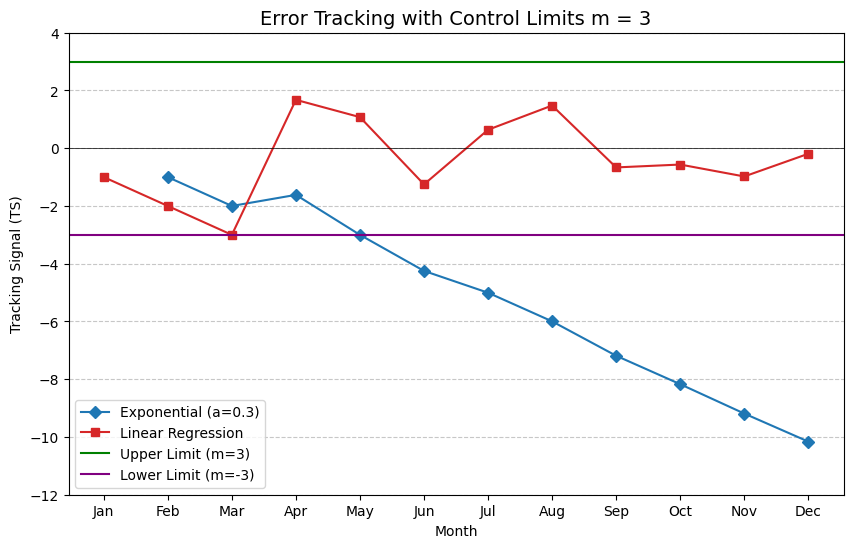

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. เตรียมข้อมูลพื้นฐาน
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
actual = [37, 40, 41, 37, 45, 50, 43, 47, 56, 52, 55, 54]
time_index = np.arange(1, 13)

df = pd.DataFrame({
    'เดือน': months,
    'หน่วยเวลา': time_index,
    'At': actual
})

# 2. คำนวณค่า Forecast (Ft)
# Linear Regression: Y = 35.2 + 1.72X
df['Ft_LR'] = 35.2 + (1.72 * df['หน่วยเวลา'])

# Exponential Smoothing (a = 0.3): F2 = A1
alpha = 0.3
es_forecast = [np.nan] * 12
es_forecast[1] = actual[0] # Jan Actual becomes Feb Forecast
for i in range(1, 11):
    es_forecast[i+1] = (alpha * actual[i]) + ((1 - alpha) * es_forecast[i])
df['Ft_Exp'] = es_forecast

# 3. ฟังก์ชันคำนวณ Error, Cumulative Error, MAD_t และ TS_t
def calculate_ts(df, forecast_col, name):
    # Error = At - Ft
    df[f'Error_{name}'] = df['At'] - df[forecast_col]
    
    # Cumulative Error = Σ(At - Ft)
    df[f'Cum_Error_{name}'] = df[f'Error_{name}'].cumsum()
    
    # MAD_t = Σ|At - Ft| / N (คำนวณแบบสะสม)
    df[f'Abs_Error_{name}'] = df[f'Error_{name}'].abs()
    df[f'MAD_{name}'] = df[f'Abs_Error_{name}'].expanding().mean()
    
    # TS_t = -(Cumulative Error / MAD_t) ตามสูตรในภาพตัวอย่าง
    df[f'TS_{name}'] = -(df[f'Cum_Error_{name}'] / df[f'MAD_{name}'])
    
    return df

df = calculate_ts(df, 'Ft_Exp', 'Exp')
df = calculate_ts(df, 'Ft_LR', 'LR')

# 4. แสดงตารางผลลัพธ์
print("### ตารางคำนวณ Error Tracking และ Tracking Signal (TS)")
pd.options.display.float_format = '{:,.2f}'.format
display(df[['เดือน', 'At', 'Ft_Exp', 'Ft_LR', 'TS_Exp', 'TS_LR']].fillna('-'))

# 5. พล็อตกราฟ Tracking Signal กับ Control Limits (m = ±3)
plt.figure(figsize=(10, 6))
plt.plot(df['เดือน'], df['TS_Exp'], marker='D', label='Exponential (a=0.3)', color='#1f77b4')
plt.plot(df['เดือน'], df['TS_LR'], marker='s', label='Linear Regression', color='#d62728')

# เพิ่มเส้น Control Limits
plt.axhline(y=3, color='g', linestyle='-', label='Upper Limit (m=3)')
plt.axhline(y=-3, color='purple', linestyle='-', label='Lower Limit (m=-3)')
plt.axhline(y=0, color='black', linewidth=0.5)

plt.title('Error Tracking with Control Limits m = 3', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Tracking Signal (TS)')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.ylim(-12, 4) # ปรับสเกลให้ใกล้เคียงกับภาพตัวอย่าง
plt.show()

# ตย

In [15]:
import numpy as np
import pandas as pd

# 1. เตรียมข้อมูลสมมติ (Actual = ค่าจริง, Forecast = ค่าที่ทำนายได้)
actual = np.array([43.16, 33.36, 18.76, 56.86])
forecast = np.array([42.55831, 33.74355, 24.28676, 54.67138])

def calculate_errors(y_true, y_pred):
    # คำนวณหาค่าความแตกต่าง (Error)
    errors = y_true - y_pred
    abs_errors = np.abs(errors)
    
    # คำนวณแต่ละ Metric
    mad = np.mean(abs_errors)
    mse = np.mean(errors**2)
    mapd = np.mean(abs_errors / np.abs(y_true)) * 100
    
    return mad, mse, mapd

# 2. เรียกใช้ฟังก์ชัน
mad, mse, mapd = calculate_errors(actual, forecast)

# 3. แสดงผลลัพธ์ในรูปแบบตารางสวยงาม
results = pd.DataFrame({
    'Metric': ['MAD', 'MSE', 'MAPD (%)'],
    'Value': [mad, mse, f"{mapd:.2f}%"]
})

print("สรุปผลการวัดประสิทธิภาพโมเดล:")
display(results)

สรุปผลการวัดประสิทธิภาพโมเดล:


,Metric,Value
0,MAD,2.175155
1,MSE,8.961069
2,MAPD (%),8.96%


In [1]:
import pandas as pd
import numpy as np

# 1. ต้องสร้าง DataFrame ให้เสร็จก่อน เพื่อให้ทราบขนาด (len) ที่แน่นอน 
data_pc = {
    't': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    'A_t': [2.54, 2.53, 3.27, 2.84, 2.99, 3.24, 3.61, 3.20, 3.44, 2.23, 2.4, 2.52, 1.71, 1.22, 1.77, 1.18, 1.32, 1.40, 1.34, 1.63, 1.31, 1.79, 2.11, 2.04]
}
df = pd.DataFrame(data_pc)

# 2. กำหนดตัวแปรหลังจากที่เรารู้ขนาดของ df แล้ว
alpha = 0.5
forecasts = [np.nan] * len(df) 

# 3. เงื่อนไขเริ่มต้นตามเอกสารหน้า 13: F2 = A1 
# (Index ใน Python เริ่มที่ 0 ดังนั้น F2 คือ index 1 และ A1 คือ index 0)
forecasts[1] = df.loc[0, 'A_t']

# 4. การคำนวณหาค่าพยากรณ์ถัดไป (เริ่มจาก t=2 เพื่อหา F ของเดือนที่ 3) [cite: 188, 195]
for t in range(2, len(df)):
    F_prev = forecasts[t-1]
    A_prev = df.loc[t-1, 'A_t']
    
    # ใช้สูตร: Ft = Ft-1 + alpha * (At-1 - Ft-1) [cite: 188, 190]
    F_new = F_prev + alpha * (A_prev - F_prev)
    forecasts[t] = F_new

df['Exp_Smooth'] = forecasts
print(df[['t', 'A_t', 'Exp_Smooth']])

     t   A_t  Exp_Smooth
0    1  2.54         NaN
1    2  2.53    2.540000
2    3  3.27    2.535000
3    4  2.84    2.902500
4    5  2.99    2.871250
5    6  3.24    2.930625
6    7  3.61    3.085313
7    8  3.20    3.347656
8    9  3.44    3.273828
9   10  2.23    3.356914
10  11  2.40    2.793457
11  12  2.52    2.596729
12  13  1.71    2.558364
13  14  1.22    2.134182
14  15  1.77    1.677091
15  16  1.18    1.723546
16  17  1.32    1.451773
17  18  1.40    1.385886
18  19  1.34    1.392943
19  20  1.63    1.366472
20  21  1.31    1.498236
21  22  1.79    1.404118
22  23  2.11    1.597059
23  24  2.04    1.853529


### ตารางคำนวณ Error Tracking และ Tracking Signal (TS)


,เดือน,A,B,MAD_A,MAD_B,TS_A,TS_B
0,1,40.30,45.52,11.70,6.48,-1.00,-1.00
1,2,43.21,47.24,5.96,5.36,-1.93,-0.42
2,3,43.15,48.96,5.59,3.89,-2.92,-0.33


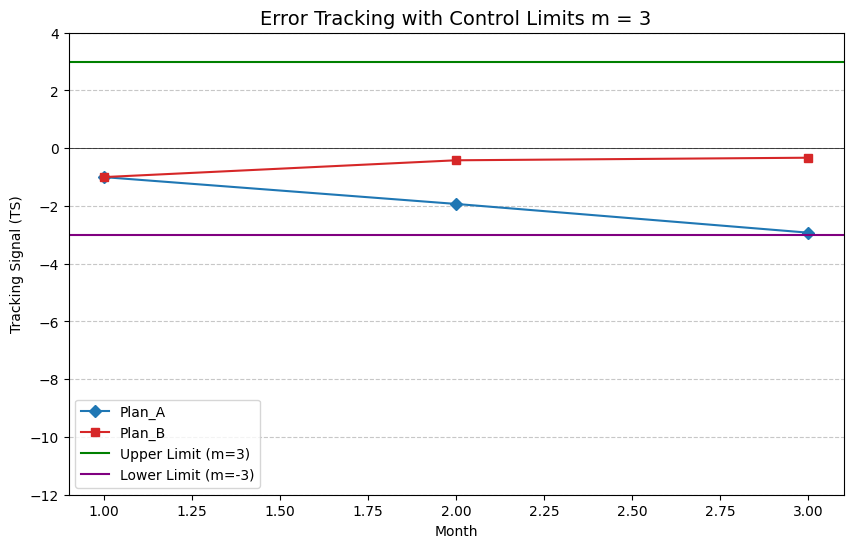

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. เตรียมข้อมูลพื้นฐาน
months = [1, 2, 3]
actual = [52, 43, 48]
A =[40.30, 43.21, 43.15]
B = [45.52, 47.24, 48.96]
time_index = np.arange(1, 4)

df = pd.DataFrame({
    'เดือน': months,
    'หน่วยเวลา': time_index,
    'At': actual,
    'A' : A,
    'B' : B,
})




# 3. ฟังก์ชันคำนวณ Error, Cumulative Error, MAD_t และ TS_t
def calculate_ts(df, forecast_col, name):
    # Error = At - Ft
    df[f'Error_{name}'] = df[f'At'] - df[forecast_col]
    
    # Cumulative Error = Σ(At - Ft)
    df[f'Cum_Error_{name}'] = df[f'Error_{name}'].cumsum()
    
    # MAD_t = Σ|At - Ft| / N (คำนวณแบบสะสม)
    df[f'Abs_Error_{name}'] = df[f'Error_{name}'].abs()
    df[f'MAD_{name}'] = df[f'Abs_Error_{name}'].expanding().mean()
    
    # TS_t = -(Cumulative Error / MAD_t) ตามสูตรในภาพตัวอย่าง
    df[f'TS_{name}'] = -(df[f'Cum_Error_{name}'] / df[f'MAD_{name}'])
    
    return df

df = calculate_ts(df, 'A', 'A')
df = calculate_ts(df, 'B', 'B')

# 4. แสดงตารางผลลัพธ์
print("### ตารางคำนวณ Error Tracking และ Tracking Signal (TS)")
pd.options.display.float_format = '{:,.2f}'.format
display(df[['เดือน', 'A', 'B','MAD_A','MAD_B', 'TS_A', 'TS_B']].fillna('-'))

# 5. พล็อตกราฟ Tracking Signal กับ Control Limits (m = ±3)
plt.figure(figsize=(10, 6))
plt.plot(df['เดือน'], df['TS_A'], marker='D', label='Plan_A', color='#1f77b4')
plt.plot(df['เดือน'], df['TS_B'], marker='s', label='Plan_B', color='#d62728')

# เพิ่มเส้น Control Limits
plt.axhline(y=3, color='g', linestyle='-', label='Upper Limit (m=3)')
plt.axhline(y=-3, color='purple', linestyle='-', label='Lower Limit (m=-3)')
plt.axhline(y=0, color='black', linewidth=0.5)

plt.title('Error Tracking with Control Limits m = 3', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Tracking Signal (TS)')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.ylim(-12, 4) # ปรับสเกลให้ใกล้เคียงกับภาพตัวอย่าง
plt.show()